# 05 · Support Vector Classifier

Two routes to the same model:

- **Route A: geometry.** Among all separating hyperplanes, pick the one with the **largest distance (margin)** to the closest points; allow some violations (soft margin).
- **Route B: loss minimisation.** Minimise a regularised **hinge loss**, exactly like we minimised regularised cross-entropy for logistic regression.

We derive both and prove that they give the same problem.

**Contents**

1. Setup and notation
2. Geometry: distance from a point to a hyperplane
3. Hard-margin SVM: maximise the margin
4. Soft-margin SVM: slack variables and $C$
5. The hinge-loss view (and the proof that it is the same problem)
6. Hinge vs. logistic loss
7. Training with sub-gradient descent (from scratch)
8. Support vectors
9. The dual problem (brief) and the kernel trick
10. Practical notes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(3)

## 1. Setup and notation

- Labels are $y^{(i)}\in\{-1, +1\}$ (not 0/1): it makes the formulas symmetric.
- Linear score: $f(\mathbf{x}) = \boldsymbol{\theta}^\top\mathbf{x} + \theta_0$, prediction $\hat{y} = \mathrm{sign}(f(\mathbf{x}))$.
- Here $\boldsymbol{\theta}\in\mathbb{R}^n$ holds only the **weights**, and the intercept $\theta_0$ is kept **separate**, because it must not appear in the margin/regulariser $\lVert\boldsymbol{\theta}\rVert$. (Books often write $\mathbf{w}, b$ for $\boldsymbol{\theta}, \theta_0$.)
- **Functional margin** of example $i$: $\;\mu^{(i)} = y^{(i)}f(\mathbf{x}^{(i)}) = y^{(i)}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)} + \theta_0)$.
  $\mu^{(i)} > 0$ ⇔ correctly classified. The larger it is, the more "confidently" correct.

Every loss in this notebook is a function of $\mu$ alone.

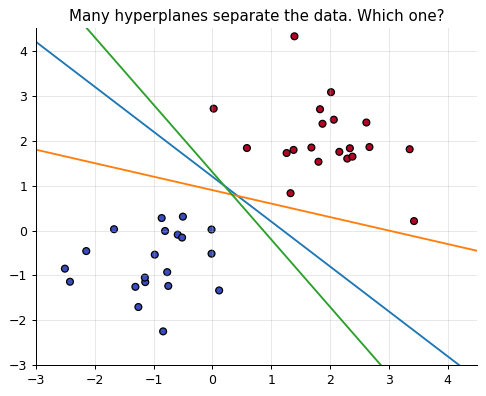

In [2]:
# Two separable clouds
m_half = 20
Xa = rng.normal([2, 2], 0.7, (m_half, 2)); Xb = rng.normal([-1, -0.5], 0.7, (m_half, 2))
X = np.r_[Xa, Xb]; y = np.r_[np.ones(m_half), -np.ones(m_half)]

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=30)
xs = np.linspace(-3, 4.5, 10)
for a, b, c in [(1, 1, -1.2), (0.3, 1, -0.9), (1.5, 1, -1.3)]:       # a x1 + b x2 + c = 0
    ax.plot(xs, -(a * xs + c) / b, lw=1.5)
ax.set_xlim(-3, 4.5); ax.set_ylim(-3, 4.5); ax.set_title("Many hyperplanes separate the data. Which one?")
plt.tight_layout(); plt.show()

## 2. Geometry: distance from a point to a hyperplane

Hyperplane $\mathcal{H} = \{\mathbf{x}: \boldsymbol{\theta}^\top\mathbf{x} + \theta_0 = 0\}$.

**$\boldsymbol{\theta}$ is perpendicular to $\mathcal{H}$.** For two points $\mathbf{x}_a, \mathbf{x}_b\in\mathcal{H}$, subtracting their equations gives $\boldsymbol{\theta}^\top(\mathbf{x}_a - \mathbf{x}_b) = 0$: $\boldsymbol{\theta}$ is orthogonal to every direction lying in the plane.

**Signed distance.** Decompose any point as $\mathbf{x} = \mathbf{x}_\perp + r\,\frac{\boldsymbol{\theta}}{\lVert\boldsymbol{\theta}\rVert}$, where $\mathbf{x}_\perp\in\mathcal{H}$ is its projection onto the plane and $r$ the signed distance. Then

$$
\boldsymbol{\theta}^\top\mathbf{x} + \theta_0 = \underbrace{\boldsymbol{\theta}^\top\mathbf{x}_\perp + \theta_0}_{=0} + r\,\frac{\boldsymbol{\theta}^\top\boldsymbol{\theta}}{\lVert\boldsymbol{\theta}\rVert} = r\lVert\boldsymbol{\theta}\rVert
\quad\Longrightarrow\quad
\boxed{r = \frac{\boldsymbol{\theta}^\top\mathbf{x} + \theta_0}{\lVert\boldsymbol{\theta}\rVert} = \frac{f(\mathbf{x})}{\lVert\boldsymbol{\theta}\rVert}}
$$

For a correctly classified example, its (unsigned) distance to the boundary is the **geometric margin**
$$
\gamma^{(i)} = \frac{y^{(i)}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)} + \theta_0)}{\lVert\boldsymbol{\theta}\rVert} = \frac{\mu^{(i)}}{\lVert\boldsymbol{\theta}\rVert}.
$$

**Scale invariance.** Multiplying $(\boldsymbol{\theta}, \theta_0)$ by any $c>0$ describes the **same** hyperplane and leaves $\gamma^{(i)}$ unchanged (numerator and denominator both scale by $c$). Only the functional margin $\mu^{(i)}$ changes. We will use this freedom to fix a convenient scale.

## 3. Hard-margin SVM (Route A, separable data)

**Goal**: maximise the smallest distance from any training point to the boundary, with all points correctly classified:

$$
\max_{\boldsymbol{\theta},\theta_0}\;\min_i\;\frac{y^{(i)}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)} + \theta_0)}{\lVert\boldsymbol{\theta}\rVert}.
$$

**Fix the scale.** Choose $c$ so that the closest points have functional margin exactly 1: $\min_i y^{(i)}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)}+\theta_0) = 1$. Then the smallest distance is $1/\lVert\boldsymbol{\theta}\rVert$, and all points satisfy $y^{(i)}f(\mathbf{x}^{(i)})\ge 1$. Maximising $1/\lVert\boldsymbol{\theta}\rVert$ is the same as minimising $\frac12\lVert\boldsymbol{\theta}\rVert^2$ (squared and halved for convenience):

$$
\boxed{\min_{\boldsymbol{\theta},\theta_0}\;\frac12\lVert\boldsymbol{\theta}\rVert^2 \quad\text{s.t.}\quad y^{(i)}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)} + \theta_0) \ge 1,\quad i=1,\dots,m}
$$

- The two lines $f(\mathbf{x}) = \pm1$ bound the **margin**, whose total width is $\frac{2}{\lVert\boldsymbol{\theta}\rVert}$.
- This is a **convex quadratic program** (convex quadratic objective, linear constraints), so it has a unique global solution.
- Why a large margin? A boundary far from all training points is robust to small perturbations of the data and, per statistical learning theory, generalises better. The bound depends on (data radius / margin)², not on the dimension $n$.

## 4. Soft-margin SVM (Route A, non-separable data)

Real data overlap, and then the hard-margin problem has no feasible solution. Allow each point a **slack** $\xi^{(i)}\ge0$ and pay for it:

$$
\boxed{\min_{\boldsymbol{\theta},\theta_0,\boldsymbol{\xi}}\;\frac12\lVert\boldsymbol{\theta}\rVert^2 + C\sum_{i=1}^m\xi^{(i)} \quad\text{s.t.}\quad y^{(i)}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)} + \theta_0) \ge 1 - \xi^{(i)},\quad \xi^{(i)}\ge0}
$$

| slack | meaning |
|---|---|
| $\xi^{(i)} = 0$ | on the correct side, outside or on the margin |
| $0 < \xi^{(i)} \le 1$ | correct side but inside the margin |
| $\xi^{(i)} > 1$ | misclassified |

$\sum_i\xi^{(i)}$ is an upper bound on the number of training mistakes. $C>0$ trades margin width against violations:
- **large $C$**: violations are expensive → narrow margin, fits the training data tightly (low bias, high variance). $C\to\infty$ recovers the hard margin.
- **small $C$**: wide margin, many violations tolerated (more regularisation).

## 5. The hinge-loss view (Route B) — and why it is the same problem

**Eliminate the slacks.** For fixed $(\boldsymbol{\theta},\theta_0)$, each $\xi^{(i)}$ appears only in its own two constraints $\xi^{(i)}\ge 1-\mu^{(i)}$ and $\xi^{(i)}\ge0$, and the objective wants it as small as possible. So at the optimum

$$
\xi^{(i)} = \max\big(0,\; 1 - \mu^{(i)}\big) = \max\big(0,\; 1 - y^{(i)}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)}+\theta_0)\big).
$$

This is the **hinge loss** $\ell_{\text{hinge}}(\mu) = \max(0, 1-\mu)$. Substituting gives an **unconstrained** problem:

$$
\min_{\boldsymbol{\theta},\theta_0}\;\frac12\lVert\boldsymbol{\theta}\rVert^2 + C\sum_{i=1}^m\max\big(0,\,1 - y^{(i)}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)}+\theta_0)\big).
$$

Divide by $Cm$ (this doesn't change the minimiser) and set $\lambda = \frac{1}{Cm}$:

$$
\boxed{J(\boldsymbol{\theta},\theta_0) = \frac{1}{m}\sum_{i=1}^m\max\big(0,\,1 - y^{(i)}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)}+\theta_0)\big) + \frac{\lambda}{2}\lVert\boldsymbol{\theta}\rVert^2}
$$

This is **"average loss + L2 regularisation"**, the same template as regularised linear and logistic regression (notebook 03). Only the loss changed. The two routes are the same problem. $\blacksquare$

**The hinge loss has three regions** (in terms of $\mu = yf(\mathbf{x})$):
- $\mu\ge1$: loss 0, flat. The point is safely classified and **has no influence at all**.
- $0\le\mu<1$: correct but inside the margin; small linear penalty.
- $\mu<0$: misclassified; penalty grows linearly.

The regulariser $\frac{\lambda}{2}\lVert\boldsymbol{\theta}\rVert^2$ is what makes the margin $2/\lVert\boldsymbol{\theta}\rVert$ wide. The hinge term pushes points outside the margin.

**Convexity.** $\max(0, 1-\mu)$ is a maximum of two affine functions of $(\boldsymbol{\theta},\theta_0)$, hence convex; plus a convex quadratic. So $J$ is convex: every local minimum is global. But it is **not differentiable** at $\mu = 1$, so we will need sub-gradients.

## 6. Hinge vs. logistic loss

Logistic regression can be written with $\pm1$ labels too. With $y\in\{-1,+1\}$ and $P(y=+1\mid\mathbf{x}) = \sigma(f)$, symmetry of the sigmoid gives $P(y\mid\mathbf{x}) = \sigma(yf)$ for both labels. The loss is

$$
-\log\sigma(yf) = \log\big(1 + e^{-yf}\big) = \log\big(1 + e^{-\mu}\big),
$$

which is just binary cross-entropy rewritten. Now both methods are "regularised loss of the margin $\mu$", and they differ only in the shape of the loss:

- Both are convex upper bounds (up to scaling) of the **0–1 loss** $\mathbb{1}[\mu\le 0]$, which is what we really want to minimise but which has zero gradient almost everywhere.
- The logistic loss is **never exactly 0**: every point, however well classified, still pulls on $\boldsymbol{\theta}$. The hinge loss is exactly 0 for $\mu\ge1$, so only points on or inside the margin matter. That is where the **sparsity** of SVMs comes from (section 8).
- Logistic regression gives probabilities; the SVM gives only a score $f(\mathbf{x})$.

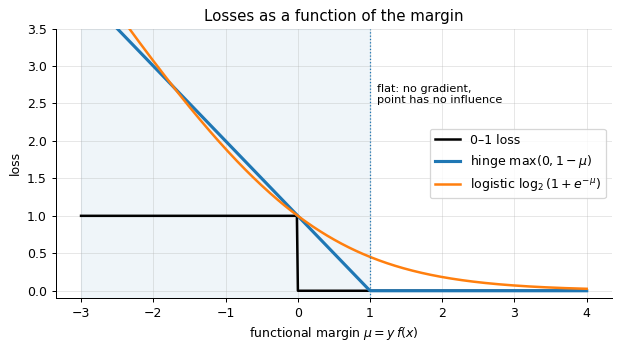

In [3]:
mu = np.linspace(-3, 4, 500)
plt.figure(figsize=(7, 4))
plt.plot(mu, (mu <= 0).astype(float), "k", lw=2, label="0–1 loss")
plt.plot(mu, np.maximum(0, 1 - mu), lw=2.5, label=r"hinge $\max(0,1-\mu)$")
plt.plot(mu, np.log2(1 + np.exp(-mu)), lw=2, label=r"logistic $\log_2(1+e^{-\mu})$")
plt.axvspan(-3, 1, color="C0", alpha=0.07); plt.axvline(1, color="C0", ls=":", lw=1)
plt.text(1.1, 2.5, "flat: no gradient,\npoint has no influence", fontsize=9)
plt.xlabel(r"functional margin $\mu = y\,f(x)$"); plt.ylabel("loss"); plt.ylim(-0.1, 3.5); plt.legend()
plt.title("Losses as a function of the margin"); plt.tight_layout(); plt.show()

## 7. Training with sub-gradient descent

**Sub-gradient.** For a convex function with a kink, a sub-gradient at a point is the slope of any line that touches the function there and stays below it. Away from kinks it is the ordinary gradient. For one hinge term with respect to $\boldsymbol{\theta}$:

$$
\partial_{\boldsymbol{\theta}}\max\big(0, 1-\mu^{(i)}\big) \ni
\begin{cases}
-y^{(i)}\mathbf{x}^{(i)} & \mu^{(i)} < 1\\
\mathbf{0} & \mu^{(i)} > 1\\
\text{anything in between; we take } \mathbf{0} & \mu^{(i)} = 1
\end{cases}
\qquad(\text{same with } \mathbf{x}^{(i)} \text{ replaced by } 1 \text{ for } \theta_0).
$$

Let $V = \{i : \mu^{(i)} < 1\}$ be the set of **margin violators**. A sub-gradient of $J$ is

$$
\mathbf{g}_{\boldsymbol{\theta}} = \lambda\boldsymbol{\theta} - \frac{1}{m}\sum_{i\in V}y^{(i)}\mathbf{x}^{(i)}, \qquad
g_{\theta_0} = -\frac{1}{m}\sum_{i\in V}y^{(i)}.
$$

**Update rule.**
$$
\boldsymbol{\theta} \leftarrow \underbrace{(1 - \eta_t\lambda)\,\boldsymbol{\theta}}_{\text{weight decay: widens the margin}} + \underbrace{\frac{\eta_t}{m}\sum_{i\in V}y^{(i)}\mathbf{x}^{(i)}}_{\text{each violator pulls the boundary away from itself}}, \qquad
\theta_0 \leftarrow \theta_0 + \frac{\eta_t}{m}\sum_{i\in V}y^{(i)} .
$$

At the optimum the two forces balance. Points outside the margin exert no force at all.

**Step size must decay.** With a constant step the sub-gradient jumps every time a point crosses $\mu=1$ and the boundary jitters forever. Use e.g. $\eta_t = \eta_0/\sqrt{1+t}$ or $1/(\lambda t)$ (the *Pegasos* algorithm, which uses one random example or a mini-batch per step and scales to millions of examples).

In [4]:
def svm_objective(theta, theta0, X, y, lam):
    mu = y * (X @ theta + theta0)
    return np.mean(np.maximum(0, 1 - mu)) + lam / 2 * theta @ theta

def svm_subgradient_descent(X, y, lam, eta0=1.0, T=5000):
    m, n = X.shape
    theta, theta0 = np.zeros(n), 0.0
    history = []
    for t in range(T):
        mu = y * (X @ theta + theta0)
        V = mu < 1                                            # margin violators
        g = lam * theta - (y[V, None] * X[V]).sum(0) / m
        g0 = -y[V].sum() / m
        eta = eta0 / np.sqrt(1 + t)
        theta, theta0 = theta - eta * g, theta0 - eta * g0
        history.append(svm_objective(theta, theta0, X, y, lam))
    return theta, theta0, np.array(history)

lam = 0.01
theta, theta0, hist = svm_subgradient_descent(X, y, lam)
print(f"from scratch: theta = {theta.round(3)}, theta0 = {theta0:.3f}, J = {hist[-1]:.4f}")

from sklearn.svm import SVC
sk = SVC(kernel="linear", C=1 / (lam * len(y))).fit(X, y)       # lambda = 1 / (C m)
print(f"sklearn SVC : theta = {sk.coef_[0].round(3)}, theta0 = {sk.intercept_[0]:.3f}, "
      f"J = {svm_objective(sk.coef_[0], sk.intercept_[0], X, y, lam):.4f}")

from scratch: theta = [1.03  0.761], theta0 = -1.001, J = 0.0082


sklearn SVC : theta = [1.03  0.761], theta0 = -1.001, J = 0.0082


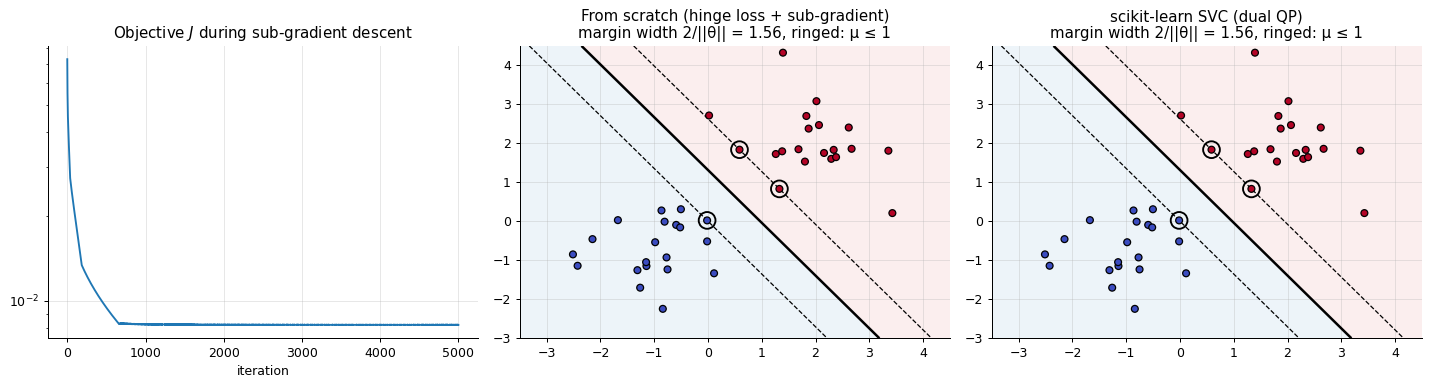

In [5]:
def plot_svm(ax, theta, theta0, X, y, title):
    g1, g2 = np.meshgrid(np.linspace(-3.5, 4.5, 300), np.linspace(-3, 4.5, 300))
    F = theta[0] * g1 + theta[1] * g2 + theta0
    ax.contourf(g1, g2, F, levels=[-1e9, 0, 1e9], colors=["C0", "C3"], alpha=0.08)
    ax.contour(g1, g2, F, levels=[-1, 0, 1], colors="k", linestyles=["--", "-", "--"], linewidths=[1, 2, 1])
    mu = y * (X @ theta + theta0)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=30, zorder=3)
    sv = mu <= 1 + 1e-3
    ax.scatter(X[sv, 0], X[sv, 1], s=180, facecolors="none", edgecolors="k", lw=1.5, zorder=4)
    ax.set_title(title + f"\nmargin width 2/||θ|| = {2/np.linalg.norm(theta):.2f}, ringed: μ ≤ 1")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
axes[0].plot(hist); axes[0].set_yscale("log"); axes[0].set_xlabel("iteration"); axes[0].set_title("Objective $J$ during sub-gradient descent")
plot_svm(axes[1], theta, theta0, X, y, "From scratch (hinge loss + sub-gradient)")
plot_svm(axes[2], sk.coef_[0], sk.intercept_[0], X, y, "scikit-learn SVC (dual QP)")
plt.tight_layout(); plt.show()

### The effect of $C$ (or $\lambda = 1/(Cm)$) on overlapping data

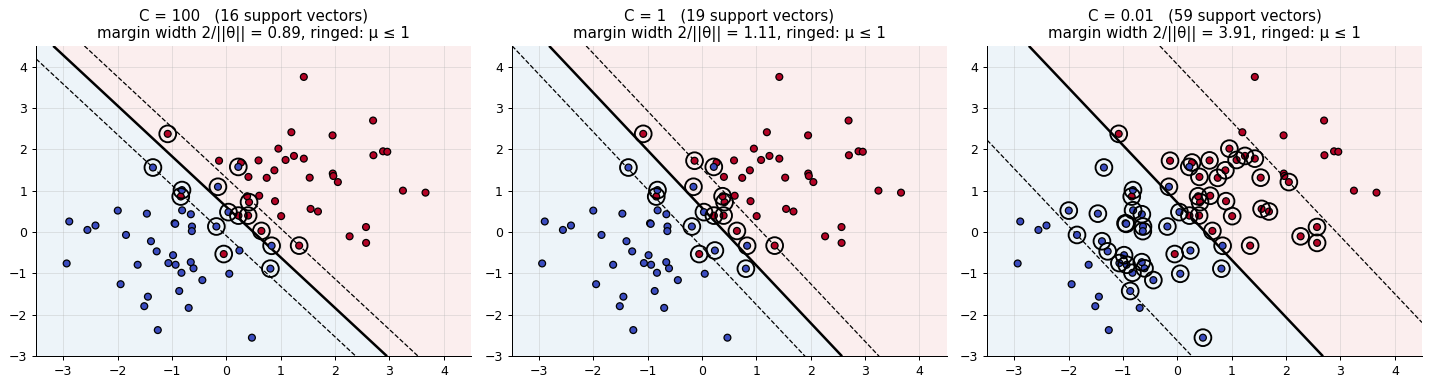

In [6]:
Xo = np.r_[rng.normal([1.2, 1.2], 1.0, (40, 2)), rng.normal([-0.8, -0.6], 1.0, (40, 2))]
yo = np.r_[np.ones(40), -np.ones(40)]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, C in zip(axes, [100, 1, 0.01]):
    s = SVC(kernel="linear", C=C).fit(Xo, yo)
    plot_svm(ax, s.coef_[0], s.intercept_[0], Xo, yo, f"C = {C}   ({len(s.support_)} support vectors)")
plt.tight_layout(); plt.show()

## 8. Support vectors

Look at the update in section 7. It starts at $\boldsymbol{\theta} = \mathbf{0}$ and only ever (a) rescales $\boldsymbol{\theta}$ and (b) adds multiples of $y^{(i)}\mathbf{x}^{(i)}$ for violators. So at every step, and at the optimum,

$$
\boldsymbol{\theta} = \sum_{i=1}^m\beta_i\,y^{(i)}\mathbf{x}^{(i)}, \qquad \beta_i \ne 0 \text{ only for points with } \mu^{(i)}\le 1 .
$$

Those points (on the margin, inside it, or misclassified) are the **support vectors**. The solution depends on them and nothing else:

- deleting or moving (on its own side, outside the margin) any other point does not change the classifier;
- this comes directly from the flat part of the hinge loss. Logistic regression has no flat part, so it uses every point.

The same fact appears in the dual (next section) as $\boldsymbol{\theta} = \sum_i\alpha_iy^{(i)}\mathbf{x}^{(i)}$ with $\alpha_i > 0$ only for support vectors.

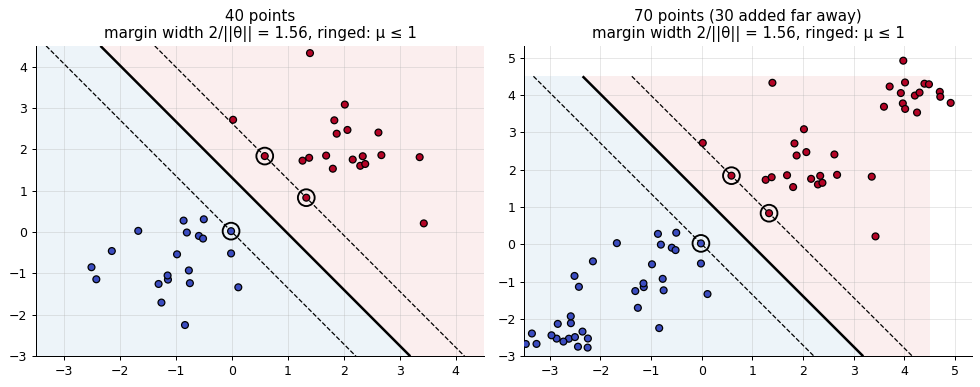

theta before: [1.0301 0.7606]  after: [1.0302 0.7605]


In [7]:
# Adding points far from the margin does not change the SVM
Xfar = np.r_[X, rng.normal([4, 4], 0.4, (15, 2)), rng.normal([-2.8, -2.5], 0.3, (15, 2))]
yfar = np.r_[y, np.ones(15), -np.ones(15)]
s1 = SVC(kernel="linear", C=1e3).fit(X, y); s2 = SVC(kernel="linear", C=1e3).fit(Xfar, yfar)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
plot_svm(axes[0], s1.coef_[0], s1.intercept_[0], X, y, f"{len(y)} points")
plot_svm(axes[1], s2.coef_[0], s2.intercept_[0], Xfar, yfar, f"{len(yfar)} points (30 added far away)")
plt.tight_layout(); plt.show()
print("theta before:", s1.coef_[0].round(4), " after:", s2.coef_[0].round(4))

## 9. The dual problem (brief) and the kernel trick

Libraries such as LIBSVM (scikit-learn's `SVC`) solve the **dual** of the constrained problem. Derivation for the hard margin, with Lagrange multipliers $\alpha_i\ge0$:

$$
\mathcal{L}(\boldsymbol{\theta},\theta_0,\boldsymbol{\alpha}) = \frac12\lVert\boldsymbol{\theta}\rVert^2 - \sum_i\alpha_i\Big[y^{(i)}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)}+\theta_0) - 1\Big].
$$

Setting derivatives to zero:
$\;\nabla_{\boldsymbol{\theta}}\mathcal{L} = 0 \Rightarrow \boldsymbol{\theta} = \sum_i\alpha_iy^{(i)}\mathbf{x}^{(i)}$, $\quad\partial\mathcal{L}/\partial\theta_0 = 0 \Rightarrow \sum_i\alpha_iy^{(i)} = 0$.
Substituting back:

$$
\max_{\boldsymbol{\alpha}}\;\sum_i\alpha_i - \frac12\sum_{i,j}\alpha_i\alpha_j\,y^{(i)}y^{(j)}\,\mathbf{x}^{(i)\top}\mathbf{x}^{(j)}
\quad\text{s.t.}\quad \alpha_i\ge0,\;\sum_i\alpha_iy^{(i)}=0 .
$$

For the soft margin the only change is $0\le\alpha_i\le C$ (the multipliers of $\xi^{(i)}\ge0$ give $C - \alpha_i - \nu_i = 0$ with $\nu_i\ge0$).

**KKT complementary slackness**: $\alpha_i\big[y^{(i)}f(\mathbf{x}^{(i)}) - 1 + \xi^{(i)}\big] = 0$. So $\alpha_i=0$ for points strictly outside the margin (the flat part of the hinge), $0<\alpha_i<C$ for points exactly on the margin, $\alpha_i = C$ for violators. Same story as the hinge loss.

**Kernel trick.** In the dual, and in $f(\mathbf{x}) = \sum_i\alpha_iy^{(i)}\,\mathbf{x}^{(i)\top}\mathbf{x} + \theta_0$, the data appear **only through dot products**. Replace them by a kernel $K(\mathbf{x},\mathbf{z}) = \phi(\mathbf{x})^\top\phi(\mathbf{z})$ and you get a linear SVM in the feature space $\phi$ without ever computing $\phi$. For example $(\mathbf{x}^\top\mathbf{z}+1)^2$ corresponds to all degree-≤2 monomials, and the RBF kernel $\exp(-\gamma\lVert\mathbf{x}-\mathbf{z}\rVert^2)$ to an infinite-dimensional $\phi$. The boundary is linear in $\phi$-space and curved in $\mathbf{x}$-space.

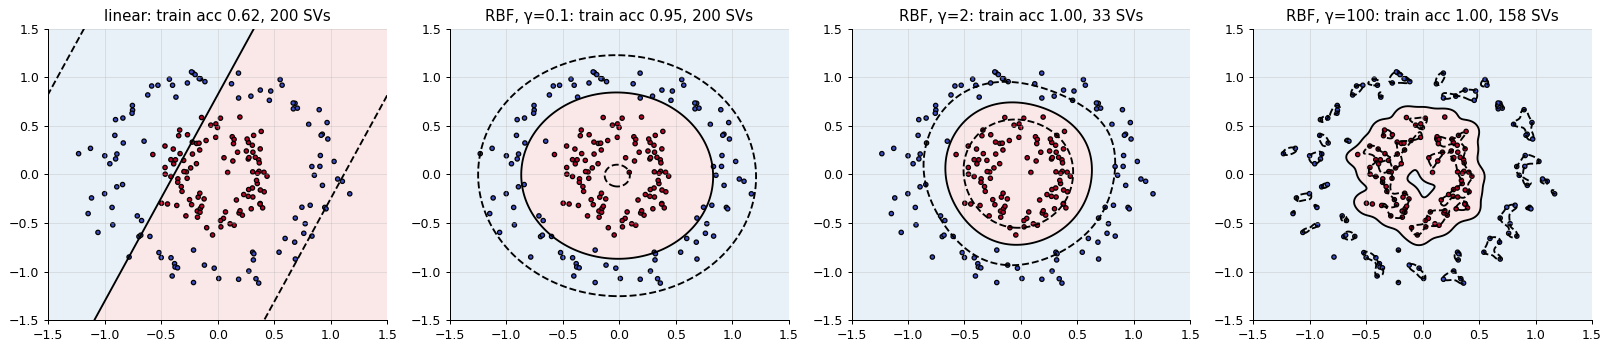

In [8]:
from sklearn.datasets import make_circles
Xc, yc = make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=0)
g1, g2 = np.meshgrid(np.linspace(-1.5, 1.5, 300), np.linspace(-1.5, 1.5, 300)); G = np.c_[g1.ravel(), g2.ravel()]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (kern, kw, name) in zip(axes, [("linear", {}, "linear"), ("rbf", {"gamma": 0.1}, "RBF, γ=0.1"),
                                       ("rbf", {"gamma": 2}, "RBF, γ=2"), ("rbf", {"gamma": 100}, "RBF, γ=100")]):
    s = SVC(kernel=kern, C=1, **kw).fit(Xc, yc); F = s.decision_function(G).reshape(g1.shape)
    ax.contourf(g1, g2, F, levels=[-1e9, 0, 1e9], colors=["C0", "C3"], alpha=0.1)
    ax.contour(g1, g2, F, levels=[-1, 0, 1], colors="k", linestyles=["--", "-", "--"])
    ax.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", edgecolor="k", s=12)
    ax.set_title(f"{name}: train acc {s.score(Xc, yc):.2f}, {len(s.support_)} SVs")
plt.tight_layout(); plt.show()

$\gamma$ sets the reach of each support vector's influence: small $\gamma$ gives smooth boundaries (can underfit), large $\gamma$ very local ones (overfits, many support vectors). Tune $C$ and $\gamma$ together by cross-validation on a log grid.

## 10. Practical notes

- **Scale the features.** The margin is a Euclidean distance, so a feature in large units dominates it.
- **No probabilities** out of the box: $f(\mathbf{x})$ is a score. `SVC(probability=True)` fits a sigmoid on top (Platt scaling) using internal CV.
- **Multiclass**: one-vs-one (`SVC`) or one-vs-rest (`LinearSVC`).
- **Cost**: kernel SVMs need the $m\times m$ kernel matrix; roughly $O(m^2)$–$O(m^3)$ training, so beyond ~$10^5$ examples use linear SVMs (sub-gradient/Pegasos, `LinearSVC`, `SGDClassifier(loss="hinge")`).
- `SVC(C=...)` corresponds to our $\lambda = 1/(Cm)$.

| | Logistic regression | Linear SVM |
|---|---|---|
| Loss of the margin $\mu$ | $\log(1+e^{-\mu})$ | $\max(0, 1-\mu)$ |
| Regulariser | L2 (usually) | L2 (always: it *is* the margin) |
| Which points matter | all | support vectors only |
| Output | calibrated probability | score / class |
| Solver | GD, Newton, L-BFGS | sub-gradient (primal) or QP/SMO (dual) |

## Summary

- Geometry: distance to the boundary is $f(\mathbf{x})/\lVert\boldsymbol{\theta}\rVert$; with the scale $\min_i\mu^{(i)}=1$, the margin width is $2/\lVert\boldsymbol{\theta}\rVert$, so maximising it = minimising $\frac12\lVert\boldsymbol{\theta}\rVert^2$ subject to $\mu^{(i)}\ge1$.
- Soft margin adds slacks with cost $C$; eliminating them gives exactly the hinge loss: $J = \frac1m\sum\max(0,1-\mu^{(i)}) + \frac\lambda2\lVert\boldsymbol{\theta}\rVert^2$, $\lambda = 1/(Cm)$.
- $J$ is convex but not differentiable → sub-gradient descent with decaying step, or the dual QP.
- Only support vectors ($\mu\le1$) determine the solution; data enter only through dot products → kernels.